## Module 3 — Pattern / Text Mining

**Initial task description (Module 3 perspective):** 
Building upon our structural refinements in modules 1 and 2, our third analysis phase shifts focus from how we formally define "listening contexts" (clustering) to how we can exploit them (recommendations). In the previous phases, our evaluation pipeline measured cluster quality using Collaborative Filtering. Although a clear-cut solution, this method is notoriously susceptible to data sparsity (Banerjee, 2024), and estimates preferences based on general alignment, which could miss the strict thematic combinations that characterize music.

To address this limitation, we pivot to Pattern Mining. By applying frequent itemset mining and association rules internally within our established clusters, we can extract co-occurrence patterns that allow use to recommend tracks based on deterministic relationships rather than generalized user similarity. While pattern mining is generally even more vulnerable to sparsity than CF, executing it within our topologically dense clusters raises local support, allowing us to capture localized rules that would be invisible at a global scale. As pattern mining prioritizes precision over broad coverage, we integrate our original Collaborative Filtering model as a dynamic fallback mechanism. Ultimately, this approach investigates a core behavioural question: within a cohesive community, is human musical curation better predicted by exact programmatic track associations, or by generalized socio-musical alignment?


In [1]:
# prelims
import pandas as pd
import os
from evaluation.evaluator import eval
from pattern_mining.rules.FPGrowGenerator import FPGrowthGenerator
from notebook_helper import compare_results 

In [2]:
# chore, load vars which we need for analysis
# load the dataframe 
from preprocessing.preprocessor import FULLY_PROCESSED_PARQUET
df = pd.read_parquet(FULLY_PROCESSED_PARQUET)
# load the tfidf matrix, unique texts and vectorizer for later use in part 2-3
from clustering.tf_idf_analysis.tf_idf_analysis import load_tfidf_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf_cache_dir = "data/tfidf_cache"
tfidf_matrix, unique_texts, vectorizer = load_tfidf_matrix(tfidf_cache_dir, df, TfidfVectorizer)

[INFO] Loading cached, cleaned TF-IDF matrix and unique texts...
[INFO] Loaded TF-IDF matrix shape: (84696, 5678)


In [3]:
# We would like to evaluate SVDKMeans, on both pure CF and hybrid
svd_kmeans_cluster_col = "svd200_kmeans_55"
hybrid_output_dir = "evaluation/reports/Hybrid_FPGrowth_CF"

### Hyperparameter Selection
The effectiveness of the association rule mining implementation relies on the calibration of two primary hyperparameters, minimum support and minimum confidence. These parameters acts as a statistical filter to ensure that only the most robust and predictive patterns are promoted to the hybrid recommendation set. 

#### Minimum Support (0.015)
Support defines the global frequency of an itemset (a combination of tracks) within a specific cluster dataset. we established a threshold of 1.5% for the following reasons.
- This particular threshold allows the FP-Growth algorithm to prune (limit) the search space of $2^d$ potential combinations efficiently, preventing the "combinatorial explosion" that occurs when dealing with high-dimensionality playlist data. Effectively decreasing the computing time. 
- Setting the *minsup* at 0.015 ensures that the engine ignores stochastic noise (track pairings that appear together purely by chance) and instead focuses on patterns that represent a consistent sub-trend within the cluster's musical community. 


#### Minimum Confidence (0.30)
Confidence measures the conditional probability of a rule, determining the likelihood that a user will listen to track *Y* given that their playlist already contains track *X*. We selected a 30% threshold based on several factors.
- We wanted a threhold which ensures that every rule generated has a statistically significant "hit rate" without being so restrictive that it only captures obvious associations. 
- We are trying to avoid the "Album Effect" which comes from setting confidence too high, ending up in captuing redundant associations, such as different tracks from the same album. 

#### Algorithmic Selection 
We have chosen FP-Growth specifically to execute this mining process due to its superior efficiency compared to the standard Apriori method. 
- Utliizing an FP-tree it stores a compressed representation of the transaction database, reducing memory overhead during the mining process. 
- By mining suffixes bottom-up through conditional FP-trees, the algorithm ensures that once the thresholds are defined, the rules are extrated with optimal time complexity relative to the data. 

In [4]:
# Defining the rule generator with desired parameters
fp_generator = FPGrowthGenerator(
    min_support_pct=0.015, # rule must appear in at least x% of transactions (playlists) to be considered
    min_confidence=0.30, 
    config_name="hybrid_test_01"
)

# Running the evaluation for the hybrid approach, which will also trigger rule mining and evaluation within the eval function

# if results already made, then skip
if os.path.exists(hybrid_output_dir):
    print(f"Results already exist in {hybrid_output_dir}, skipping evaluation.")
else:
    eval(
        df=df, 
        cluster_col=svd_kmeans_cluster_col, 
        unique_texts=unique_texts, 
        tfidf_matrix=tfidf_matrix, 
        output_dir=hybrid_output_dir,
        rule_generator=fp_generator, # trigger rule mining and evaluation within the eval function
    )

Results already exist in evaluation/reports/Hybrid_FPGrowth_CF, skipping evaluation.


In [18]:
# Now we can analyze the generated rules and their relationship to the evaluation metrics
from evaluation.rule_analysis_helper import AssociationRuleAnalyzer
analyzer = AssociationRuleAnalyzer('pattern_mining/reports/FPGrowth/hybrid_test_01')

We utilize Lift as a critical quality filter to solve the "Popularity Trap" inherent in music data. While Support and Confidence can be high for global "hits" (e.g., a chart-topping pop song that appears in many diverse playlists), such recommendations often lack personal relevance.

Lift is calculated as the ratio of the observed support to the expected support if the two items were completely independent. 
$$\text{(eq 1)}: \text{Lift}(A \rightarrow B) = \frac{\text{Confidence}(A \rightarrow B)}{\text{Support($B$})}.$$
The value of Lift is generally interpreted against a baseline of 1:
- Lift > 1 means that there is a positive correlation. 
- Lift = 1 implies no relationship between A and B. 

In [7]:
analyzer.print_average_lift()

Average Lift across all clusters: 17.8704


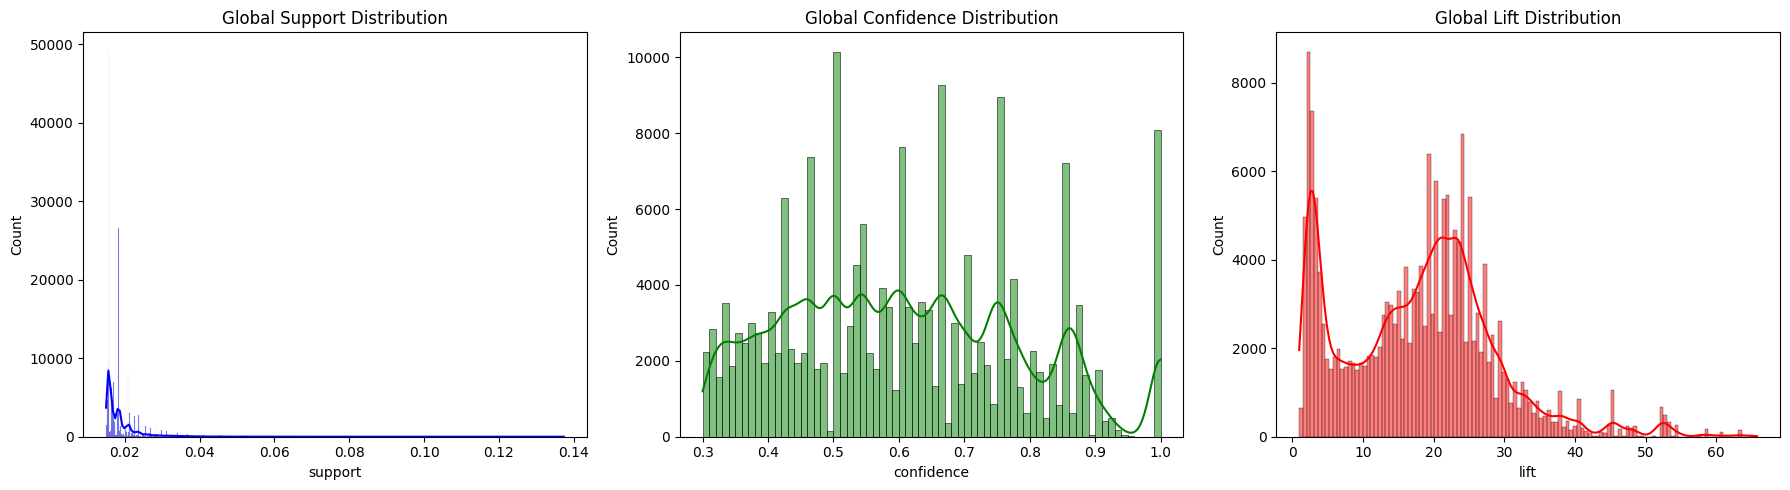

In [6]:
analyzer.plot_metric_distributions()

The most notable thing here is that there's a large concentration of rules which have a lift barely breaking $1.0$ showing slight correlation, but indicating weakness. We also have some frequently occuring extremas receiving a confidence score of exactly 1.0, we found this to often occur in well partitioned clusters like 7.0 (which represents christmas songs), where a rule such as
$$\{\text{Little Drummer Boy}\} \Rightarrow \{\text{The First Noel}\}, \text{confidence} = 1.0$$
implies that whenever Little Drummer Boy occurs, then The First Noel co-occurs. 

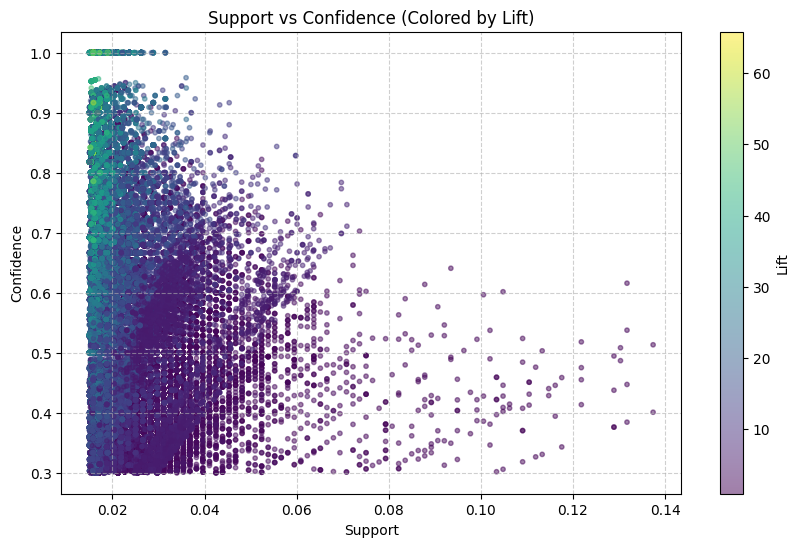

In [8]:
analyzer.plot_support_vs_confidence()

We decided on a minimum support cutoff of $1.5%$ and a confidence $>30%$ to avoid a combinatorial explosion and the occurence of weak rules. In above plots it is evident that had both been decreased the concentration of points (rules) would increase. There are a lot of purple-ish points with a support value higher than the threshold, indicating that the rules with a low enough confidence does not get a high lift score, while those points that have a high confidence and low support are found to be with a high lift proving the inverse relationship between support and lift following (eq 1). 

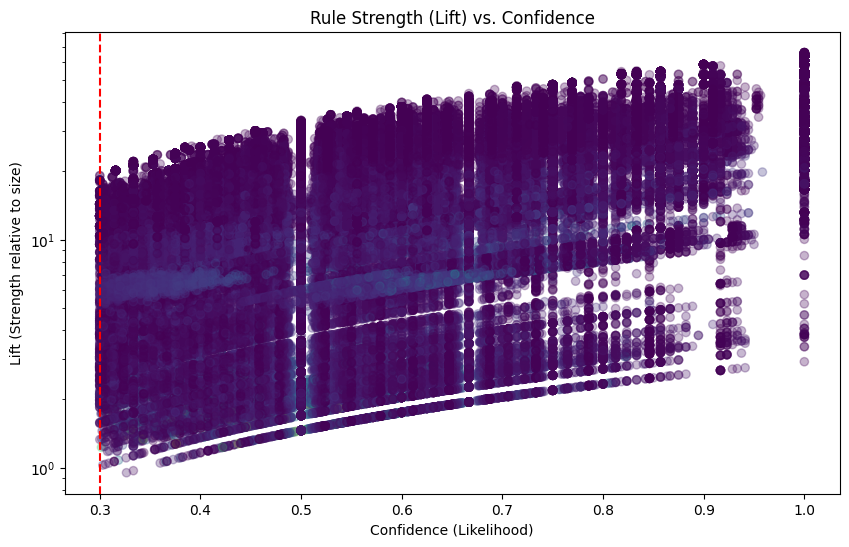

In [10]:
analyzer.plot_quality_diagnostics()

### Evaluation

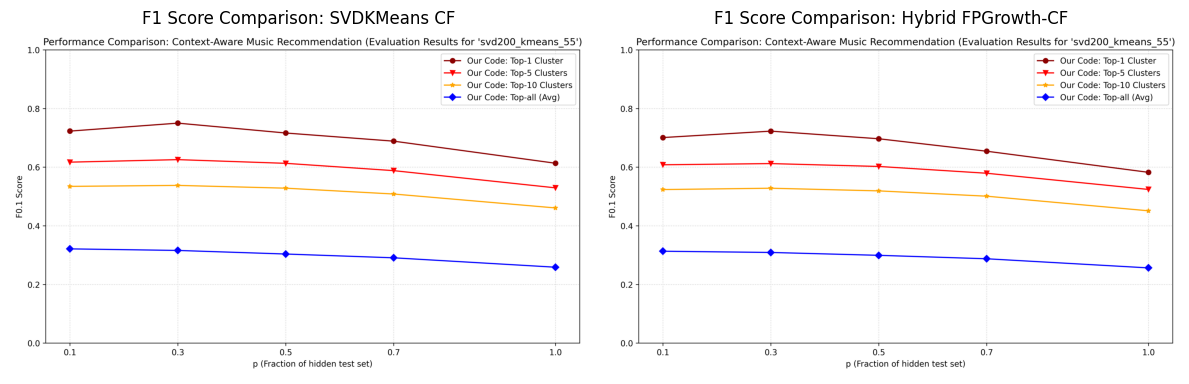

In [11]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Plotting the results
cf_f_score_plot = "clustering/reports/SVDKMeans/svd200_k55_ninit10_maxiter300/f01_comparison.png"
rules_cf_f_score_plot = "evaluation/reports/Hybrid_FPGrowth_CF/f01_comparison.png"
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

ax[0].imshow(mpimg.imread(cf_f_score_plot))
ax[0].set_title("F1 Score Comparison: SVDKMeans CF")
ax[0].axis('off')

ax[1].imshow(mpimg.imread(rules_cf_f_score_plot))
ax[1].set_title("F1 Score Comparison: Hybrid FPGrowth-CF")
ax[1].axis('off')

plt.tight_layout()
plt.show()

In [12]:
# Better more detailed viewing
hybrid_txt = "evaluation/reports/Hybrid_FPGrowth_CF/evaluation_metrics_svd200_kmeans_55.txt"
pure_cf_txt = "clustering/reports/SVDKMeans/svd200_k55_ninit10_maxiter300/evaluation_metrics_svd200_kmeans_55.txt"

if os.path.exists(pure_cf_txt) and os.path.exists(hybrid_txt):
    flat_df, table = compare_results(pure_cf_txt, hybrid_txt)
    display(table)
else:
    print("Check your file paths; one or both reports are missing.")

#### Structural Trade-offs in Recommendation Precision (interpretation of CF vs. Rules + CF)
A comparative analysis of the F0.1 scores across varying metric depths ($p$) reveals a marginal, yet systematic, performance reduction in the hybrid model compared to the pure collaborative filtering (CF) baseline. As evidenced in the **Delta** values, the integration of FP-Growth association rules resulted in a consistent decrease in F0.1 scores for the **Top-1** and **Top-5** cluster tiers, with the most pronounced deficit occuring at $p = 1.0$ for the Top-1 cluster ($-0.0216$). 

#### Aforementioned "Album Effect" and Retrieval Diversity


The high Jaccard similarity and Lift metrics observed in the rule mining phase (reaching up to 20.0+ in some clusters) indicate that the FP-Growth component predominantly captures intra-album associations or "perfectly" correlated track sequences. While these rules provide high precision for navigational or structured listering patterns, their dominance at the top of the ranked list limits the retrieval capabilities of the CF model. 

The data confirms this through the metric detph decay, as $p$ increases, the hybrid model's deficit typically grows. This suggests that while rules are effective for immediate, high-confidence "next-track" prediction, they are less capable of populating a broader, diverse recommendation set compared to the SVDKMeans baseline. 

The results indicate that while the hybrid FP-Growth-CF architecture introduced a robust mechanism for rule-based interpretability, it requires careful calibration of the rule-to-CF injection ratio. 

In [15]:
# el muchacho betterino
refined_output_dir = hybrid_output_dir + "/refine_results"
if os.path.exists(refined_output_dir):
    print(f"Refined results already exist in {refined_output_dir}, skipping re-evaluation.")
else:
     eval(df=df,
          cluster_col=svd_kmeans_cluster_col, 
          unique_texts=unique_texts, 
          tfidf_matrix=tfidf_matrix, 
          output_dir=refined_output_dir,
          rule_generator=fp_generator,
          refine_results=True, 
     )

Refined results already exist in evaluation/reports/Hybrid_FPGrowth_CF/refine_results, skipping re-evaluation.


In [16]:
# Better more detailed viewing
hybrid_txt = "evaluation/reports/Hybrid_FPGrowth_CF/refine_results/evaluation_metrics_svd200_kmeans_55.txt"
pure_cf_txt = "clustering/reports/SVDKMeans/svd200_k55_ninit10_maxiter300/evaluation_metrics_svd200_kmeans_55.txt"

if os.path.exists(pure_cf_txt) and os.path.exists(hybrid_txt):
    flat_df, table = compare_results(pure_cf_txt, hybrid_txt)
    display(table)
else:
    print("Check your file paths; one or both reports are missing.")